In [1]:
import torch
import torch.nn as nn


class CNN1D_v1(nn.Module):

    def __init__(self, num_classes: int = 3):
        super().__init__()
        # Stack: Conv → BN → ReLU → Pool (repeat / deepen as needed)
        self.features = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=4, stride=4),
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=4, stride=4),
            # Global pooling: output [B, 64, 1] regardless of length (within reason)
            nn.AdaptiveAvgPool1d(output_size=1),
        )
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x shape: [B, 1, T]
        h = self.features(x)
        h = h.squeeze(-1)
        return self.classifier(h)


# Sanity check shapes (adjust T to match your crop length)
if __name__ == "__main__":
    batch, channels, T = 4, 1, 37_000  # e.g. 5 s × 7400 Hz
    model = CNN1D_v1(num_classes=3)
    dummy = torch.randn(batch, channels, T)
    logits = model(dummy)
    print("Input:", dummy.shape)
    print("Output (logits):", logits.shape)  # [B, num_classes]


Input: torch.Size([4, 1, 37000])
Output (logits): torch.Size([4, 3])


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import random
import os
import time

def test_accuracy(model, loss_fn, val_loader, device):
    correct = 0
    total = 0
    total_loss = 0.0

    model.eval()
    with torch.no_grad():
        for x, labels in val_loader:
            x, labels = x.to(device), labels.to(device)
            outputs = model(x)

            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Calculate loss
            loss = loss_fn(outputs, labels)
            total_loss += loss.item() * x.size(0)

    if total == 0:
        raise RuntimeError("val_loader produced no samples")

    accuracy = 100.0 * correct / total
    avg_loss = total_loss / total

    model.train()
    return accuracy, avg_loss

# Train Function
def train(model, loss_fn, optimizer, train_loader, val_loader, num_epochs, device):

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    epoch_durations = []

    model.train()
    # Iterate through all Epochs
    for epoch in range(num_epochs):
        total_loss = 0
        total = 0
        correct = 0
        start_time = time.time() # Record epoch start time

        # Iterate through training dataset
        for x, labels in train_loader:
            # Load x / labels
            x, labels = x.to(device), labels.to(device)
            # Zero collected gradients at each step
            optimizer.zero_grad()
            # Forward Propagate
            outputs = model(x)
            # Calculate Loss
            loss = loss_fn(outputs, labels)
            # Back propagate
            loss.backward()
            # Update weights
            optimizer.step()

            # track loss during current epoch
            total_loss += loss.item() * x.size(0)

            # track correct predictions during current epoch
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # store loss and accuracy for current epoch
        train_losses.append(total_loss / len(train_loader.dataset))
        train_accuracies.append(100 * correct / total)

        # run model on val data and store val loss and accuracy
        val_accuracy, val_loss = test_accuracy(model, loss_fn, val_loader, device)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        # Print statistics after every epoch
        print('Epoch [%d/%d], Training Loss: %.4f, Training Accuracy: %.4f, Validation Loss: %.4f, Validation Accuracy: %.4f'
                %(epoch+1, num_epochs,
                train_losses[-1], train_accuracies[-1],
                val_losses[-1], val_accuracies[-1]))

        end_time = time.time()
        epoch_duration = end_time - start_time
        print(f'Epoch {epoch+1} finished in {epoch_duration:.2f} seconds')
        epoch_durations.append(epoch_duration)

    return train_losses, train_accuracies, val_losses, val_accuracies, epoch_durations
    
def plot_learning_curves(train_losses, val_losses, train_accs, val_accs):
    train_losses = [t.cpu().numpy() if isinstance(t, torch.Tensor) else t for t in train_losses]
    val_losses = [t.cpu().numpy() if isinstance(t, torch.Tensor) else t for t in val_losses]
    train_accs = [t.cpu().numpy() if isinstance(t, torch.Tensor) else t for t in train_accs]
    val_accs = [t.cpu().numpy() if isinstance(t, torch.Tensor) else t for t in val_accs]
    
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Val Loss")
    plt.title("Loss Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, label="Train Acc")
    plt.plot(epochs, val_accs, label="Val Acc")
    plt.title("Accuracy Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [5]:
from pathlib import Path

from torch.utils.data import DataLoader

from utils.vibration_data import make_train_val_datasets

# Jupyter: cwd should be the repo root (`174-SeniorDesign-VibrationDetection`) when you open the folder.
PROJECT_ROOT = Path.cwd()
INDEX_CSV = PROJECT_ROOT / "dataset" / "index.csv"
sample_rate = 7400

if not INDEX_CSV.is_file():
    raise FileNotFoundError(
        f"Missing {INDEX_CSV}. Export the dataset from clip_separation.ipynb first, "
        "or set the notebook working directory to the repo root."
    )

train_ds, val_ds = make_train_val_datasets(
    str(INDEX_CSV),
    train_ratio=0.7,
    seed=42,
    sample_rate=sample_rate,
    window_seconds=8.0,
    normalize="zscore",
)

batch_size = 26
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader), "| Val batches:", len(val_loader))


Train batches: 1 | Val batches: 3


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else
                      "xpu" if torch.xpu.is_available() else
                      "cpu")

print(f"Using device: {device}")

# comment out the two lines below to continue training instead of restarting training
model = CNN1D_v1(num_classes=3)
model.to(device)

num_epochs = 100
lr = 1e-3

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

train_losses, train_accs, val_losses, val_accs, epoch_durations = train(model, loss_function, optimizer, train_loader, val_loader, num_epochs, device)

Using device: xpu
Epoch [1/100], Training Loss: 1.3932, Training Accuracy: 34.6154, Validation Loss: 1.1222, Validation Accuracy: 36.3636
Epoch 1 finished in 1.18 seconds
Epoch [2/100], Training Loss: 1.2847, Training Accuracy: 34.6154, Validation Loss: 1.1120, Validation Accuracy: 36.3636
Epoch 2 finished in 0.19 seconds
Epoch [3/100], Training Loss: 1.2077, Training Accuracy: 34.6154, Validation Loss: 1.1039, Validation Accuracy: 36.3636
Epoch 3 finished in 0.19 seconds
Epoch [4/100], Training Loss: 1.1495, Training Accuracy: 34.6154, Validation Loss: 1.0971, Validation Accuracy: 53.0303
Epoch 4 finished in 0.20 seconds
Epoch [5/100], Training Loss: 1.1162, Training Accuracy: 34.6154, Validation Loss: 1.0924, Validation Accuracy: 43.9394
Epoch 5 finished in 0.18 seconds
Epoch [6/100], Training Loss: 1.0638, Training Accuracy: 46.1538, Validation Loss: 1.0881, Validation Accuracy: 31.8182
Epoch 6 finished in 0.19 seconds
Epoch [7/100], Training Loss: 1.0375, Training Accuracy: 50.0000

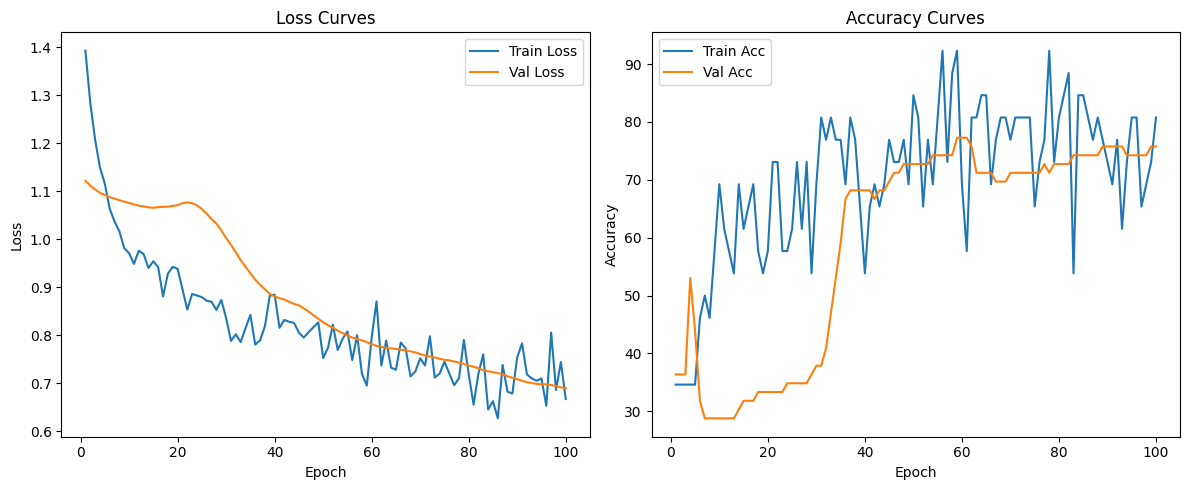

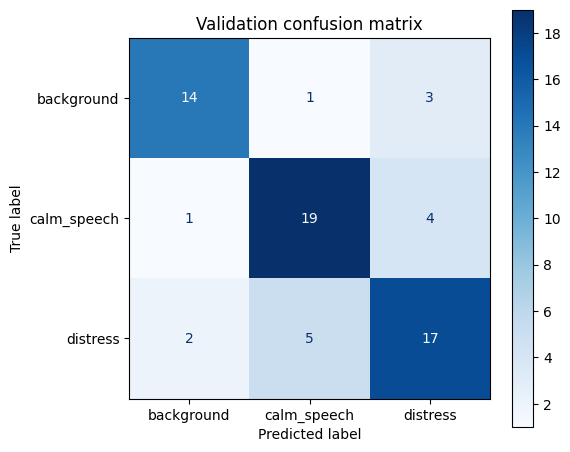

CNN1D_v1(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(2,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(2,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (8): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Linear(in_features=64, out_features=3, bias=True)
)

In [7]:
plot_learning_curves(train_losses, val_losses, train_accs, val_accs)

# Validation confusion matrix — run after training so `model`, `val_loader`, and `device` are defined.
label_names = ["background", "calm_speech", "distress"]

model.eval()
all_true, all_pred = [], []
with torch.no_grad():
    for x, labels in val_loader:
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(dim=1)
        all_true.append(labels.cpu().numpy())
        all_pred.append(preds.cpu().numpy())

y_true = np.concatenate(all_true)
y_pred = np.concatenate(all_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred, labels=np.arange(len(label_names))),
    display_labels=label_names,
)
disp.plot(ax=ax, values_format="d", cmap="Blues")
ax.set_title("Validation confusion matrix")
plt.tight_layout()
plt.show()

# restore training mode if you continue tuning
model.train()